### Base code + integrated gradients testing on DeBERTa

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from transformers import AutoTokenizer, AutoModelForQuestionAnswering
from captum.attr import visualization as viz
from captum.attr import LayerIntegratedGradients

/Users/sagi/Data_Science/RA/xai-CheMLT-F/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- [2] Device setup ---
device = torch.device("mps")

In [3]:
# --- [3] Load fine-tuned DeBERTa-v3 model ---
model_name = "deepset/deberta-v3-base-squad2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)
model.to(device)
model.eval()
model.zero_grad()

In [4]:
# --- [4] Forward pass helper ---
def predict(inputs, token_type_ids=None, position_ids=None, attention_mask=None):
    output = model(inputs,
                   token_type_ids=token_type_ids,
                   position_ids=position_ids,
                   attention_mask=attention_mask)
    return output.start_logits, output.end_logits


In [5]:
# --- [5] Custom forward for Captum ---
def squad_pos_forward_func(inputs, token_type_ids=None, position_ids=None, attention_mask=None, position=0):
    pred = predict(inputs,
                   token_type_ids=token_type_ids,
                   position_ids=position_ids,
                   attention_mask=attention_mask)
    pred = pred[position]
    return pred.max(1).values


In [6]:
# --- [6] Token reference ids ---
ref_token_id = tokenizer.pad_token_id
sep_token_id = tokenizer.sep_token_id
cls_token_id = tokenizer.cls_token_id


In [7]:
# --- [7] Helper constructors ---
def construct_input_ref_pair(question, text, ref_token_id, sep_token_id, cls_token_id):
    question_ids = tokenizer.encode(question, add_special_tokens=False)
    text_ids = tokenizer.encode(text, add_special_tokens=False)

    input_ids = [cls_token_id] + question_ids + [sep_token_id] + text_ids + [sep_token_id]
    ref_input_ids = [cls_token_id] + [ref_token_id]*len(question_ids) + [sep_token_id] + \
                    [ref_token_id]*len(text_ids) + [sep_token_id]
    return torch.tensor([input_ids], device=device), torch.tensor([ref_input_ids], device=device), len(question_ids)

def construct_input_ref_token_type_pair(input_ids, sep_ind=0):
    seq_len = input_ids.size(1)
    token_type_ids = torch.tensor([[0 if i <= sep_ind else 1 for i in range(seq_len)]], device=device)
    ref_token_type_ids = torch.zeros_like(token_type_ids, device=device)
    return token_type_ids, ref_token_type_ids

def construct_input_ref_pos_id_pair(input_ids):
    seq_length = input_ids.size(1)
    position_ids = torch.arange(seq_length, dtype=torch.long, device=device)
    ref_position_ids = torch.zeros(seq_length, dtype=torch.long, device=device)
    position_ids = position_ids.unsqueeze(0).expand_as(input_ids)
    ref_position_ids = ref_position_ids.unsqueeze(0).expand_as(input_ids)
    return position_ids, ref_position_ids

def construct_attention_mask(input_ids):
    return torch.ones_like(input_ids)

# Note: DeBERTa's embedding module name is different from BERT's
def construct_whole_embeddings(input_ids, ref_input_ids, \
                               token_type_ids=None, ref_token_type_ids=None, \
                               position_ids=None, ref_position_ids=None):
    input_emb = model.deberta.embeddings(input_ids, token_type_ids=token_type_ids, position_ids=position_ids)
    ref_emb = model.deberta.embeddings(ref_input_ids, token_type_ids=ref_token_type_ids, position_ids=ref_position_ids)
    return input_emb, ref_emb


In [8]:
# --- [8] Define question and context ---
question = "What is important to us?"
text = "It is important to us to include, empower and support humans of all kinds."


In [9]:
# --- [9] Numericalize ---
input_ids, ref_input_ids, sep_id = construct_input_ref_pair(question, text, ref_token_id, sep_token_id, cls_token_id)
token_type_ids, ref_token_type_ids = construct_input_ref_token_type_pair(input_ids, sep_id)
position_ids, ref_position_ids = construct_input_ref_pos_id_pair(input_ids)
attention_mask = construct_attention_mask(input_ids)

indices = input_ids[0].detach().tolist()
all_tokens = tokenizer.convert_ids_to_tokens(indices)


In [10]:
# --- [10] Ground truth span ---
ground_truth = "to include, empower and support humans of all kinds"
ground_truth_tokens = tokenizer.encode(ground_truth, add_special_tokens=False)
ground_truth_end_ind = indices.index(ground_truth_tokens[-1])
ground_truth_start_ind = ground_truth_end_ind - len(ground_truth_tokens) + 1


In [11]:
# --- [11] Prediction ---
start_scores, end_scores = predict(input_ids,
                                   token_type_ids=token_type_ids,
                                   position_ids=position_ids,
                                   attention_mask=attention_mask)

print("Question:", question)
print("Predicted Answer:", " ".join(all_tokens[torch.argmax(start_scores) : torch.argmax(end_scores)+1]))


Question: What is important to us?
Predicted Answer: ▁to ▁include , ▁empower ▁and ▁support ▁humans ▁of ▁all ▁kinds


In [12]:
# --- [12] Attribution via LayerIntegratedGradients ---
lig = LayerIntegratedGradients(squad_pos_forward_func, model.deberta.embeddings)

attributions_start, delta_start = lig.attribute(inputs=input_ids,
                                  baselines=ref_input_ids,
                                  additional_forward_args=(token_type_ids, position_ids, attention_mask, 0),
                                  return_convergence_delta=True)

attributions_end, delta_end = lig.attribute(inputs=input_ids,
                                baselines=ref_input_ids,
                                additional_forward_args=(token_type_ids, position_ids, attention_mask, 1),
                                return_convergence_delta=True)


In [13]:
# --- [13] Summarization helper ---
def summarize_attributions(attributions):
    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    return attributions


In [14]:
# --- [14] Summarize results ---
attributions_start_sum = summarize_attributions(attributions_start)
attributions_end_sum = summarize_attributions(attributions_end)


In [15]:
# --- [15] Visualization ---
start_position_vis = viz.VisualizationDataRecord(
    attributions_start_sum,
    torch.max(torch.softmax(start_scores[0], dim=0)),
    torch.argmax(start_scores),
    torch.argmax(start_scores),
    str(ground_truth_start_ind),
    attributions_start_sum.sum(),
    all_tokens,
    delta_start
)

end_position_vis = viz.VisualizationDataRecord(
    attributions_end_sum,
    torch.max(torch.softmax(end_scores[0], dim=0)),
    torch.argmax(end_scores),
    torch.argmax(end_scores),
    str(ground_truth_end_ind),
    attributions_end_sum.sum(),
    all_tokens,
    delta_end
)

print("\033[1mVisualizations For Start Position\033[0m")
viz.visualize_text([start_position_vis])

print("\033[1mVisualizations For End Position\033[0m")
viz.visualize_text([end_position_vis])


Visualizations For Start Position


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
13,13 (0.77),13,1.42,"[CLS] ▁What ▁is ▁important ▁to ▁us ? [SEP] ▁It ▁is ▁important ▁to ▁us ▁to ▁include , ▁empower ▁and ▁support ▁humans ▁of ▁all ▁kinds . [SEP]"


Visualizations For End Position


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
22,22 (0.58),22,1.15,"[CLS] ▁What ▁is ▁important ▁to ▁us ? [SEP] ▁It ▁is ▁important ▁to ▁us ▁to ▁include , ▁empower ▁and ▁support ▁humans ▁of ▁all ▁kinds . [SEP]"


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
22,22 (0.58),22,1.15,"[CLS] ▁What ▁is ▁important ▁to ▁us ? [SEP] ▁It ▁is ▁important ▁to ▁us ▁to ▁include , ▁empower ▁and ▁support ▁humans ▁of ▁all ▁kinds . [SEP]"


### Testing on InputXgradient

In [27]:
from captum.attr import LayerGradientXActivation

grad_x_act = LayerGradientXActivation(squad_pos_forward_func, model.deberta.embeddings)

# Compute attributions for start and end positions
attributions_start= grad_x_act.attribute(
    inputs=input_ids,
    additional_forward_args=(token_type_ids, position_ids, attention_mask, 0),
)

attributions_end= grad_x_act.attribute(
    inputs=input_ids,
    additional_forward_args=(token_type_ids, position_ids, attention_mask, 1),
)


In [29]:
def summarize_attributions(attributions):
    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    return attributions

attributions_start_sum = summarize_attributions(attributions_start)
attributions_end_sum = summarize_attributions(attributions_end)


In [30]:
from captum.attr import visualization as viz

start_vis = viz.VisualizationDataRecord(
    attributions_start_sum,
    torch.max(torch.softmax(start_scores[0], dim=0)),
    torch.argmax(start_scores),
    torch.argmax(start_scores),
    str(ground_truth_start_ind),
    attributions_start_sum.sum(),
    all_tokens,
    delta_start
)

end_vis = viz.VisualizationDataRecord(
    attributions_end_sum,
    torch.max(torch.softmax(end_scores[0], dim=0)),
    torch.argmax(end_scores),
    torch.argmax(end_scores),
    str(ground_truth_end_ind),
    attributions_end_sum.sum(),
    all_tokens,
    delta_end
)

print("\033[1mVisualizations For Start Position (Input × Gradient)\033[0m")
viz.visualize_text([start_vis])

print("\033[1mVisualizations For End Position (Input × Gradient)\033[0m")
viz.visualize_text([end_vis])


Visualizations For Start Position (Input × Gradient)


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
13,13 (0.77),13,-0.95,"[CLS] ▁What ▁is ▁important ▁to ▁us ? [SEP] ▁It ▁is ▁important ▁to ▁us ▁to ▁include , ▁empower ▁and ▁support ▁humans ▁of ▁all ▁kinds . [SEP]"


Visualizations For End Position (Input × Gradient)


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
22,22 (0.58),22,-1.51,"[CLS] ▁What ▁is ▁important ▁to ▁us ? [SEP] ▁It ▁is ▁important ▁to ▁us ▁to ▁include , ▁empower ▁and ▁support ▁humans ▁of ▁all ▁kinds . [SEP]"


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
22,22 (0.58),22,-1.51,"[CLS] ▁What ▁is ▁important ▁to ▁us ? [SEP] ▁It ▁is ▁important ▁to ▁us ▁to ▁include , ▁empower ▁and ▁support ▁humans ▁of ▁all ▁kinds . [SEP]"


### Testing on SHAP

In [39]:
import datasets
import pandas as pd
import transformers

import shap

# load the emotion dataset
dataset = datasets.load_dataset("emotion", split="train")
data = pd.DataFrame({"text": dataset["text"], "emotion": dataset["label"]})

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Generating test split: 100%|██████████| 2000/2000 [00:00<00:00, 1025126.24 examples/s]


In [45]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_name = "AnkitAI/deberta-v3-small-base-emotions-classifier"
model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [46]:
# build a pipeline object to do predictions
pred = transformers.pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0,
    return_all_scores=True,
)

/Users/sagi/Data_Science/RA/xai-CheMLT-F/venv/lib/python3.10/site-packages/transformers/pipelines/text_classification.py:104: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [48]:
explainer = shap.Explainer(pred)

/Users/sagi/Data_Science/RA/xai-CheMLT-F/venv/lib/python3.10/site-packages/transformers/deepspeed.py:24: FutureWarning: transformers.deepspeed module is deprecated and will be removed in a future version. Please import deepspeed modules directly from transformers.integrations
  warnings.warn(


In [49]:
shap_values = explainer(data["text"][:3])

PartitionExplainer explainer: 4it [00:16,  8.04s/it]               


In [50]:
shap.plots.text(shap_values)

In [51]:
shap.plots.text(shap_values[:, :, "anger"])


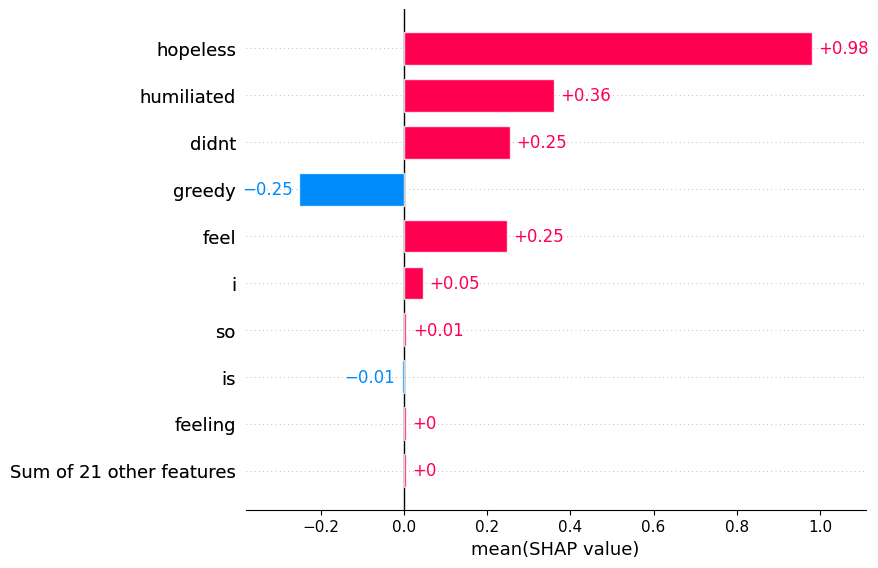

In [53]:
shap.plots.bar(shap_values[:, :, "sadness"].mean(0))
